Q1. You are a data analyst at an e-commerce company. Your task isto analyze sales data, clean and process it, perform statistical analysis, and generate visual insights to help the business make informed decisions.

Part I: Randomized Sales Data Generation (NumPy)
In this part, I first initialized the random seed using my roll number (8025320017) to ensure that the generated data is unique and reproducible. Since NumPy only accepts seed values within a specific range, I converted my roll number into a valid seed using the modulo operation. After setting the seed, I generated a NumPy array of shape (12, 4) representing sales data for 12 months and 4 product categories: Electronics, Clothing, Home & Kitchen, and Sports. The sales values were randomly generated between 1000 and 5000 units. Finally, I converted the NumPy array into a Pandas DataFrame and labeled the columns with product names and the rows with months from January to December to make the data structured and easier to analyze further.

In [4]:
import numpy as np
import pandas as pd
roll_number = 8025320017
# Convert roll number into valid seed range
seed_value = roll_number % (2**32)
np.random.seed(seed_value)

In [5]:
# Here we are generate random sales data
# 12 rows for months and 4 columns for categories. Values between 1000 and 5000 (5001 is used because upper limit is exclusive)
sales_data = np.random.randint(1000, 5001, size=(12, 4))
sales_data #To display the result

array([[3844, 2029, 2955, 1504],
       [4602, 1215, 2901, 4483],
       [1972, 1808, 1803, 3283],
       [2563, 3949, 3752, 1901],
       [4044, 2524, 1172, 2633],
       [1066, 3358, 1207, 4784],
       [4336, 1717, 4664, 4128],
       [1704, 1561, 2684, 2406],
       [3920, 3846, 4720, 4618],
       [4789, 2601, 1807, 3019],
       [2353, 1184, 3768, 2296],
       [3329, 3068, 1511, 3702]])

In [6]:
# Define product categories as column names
columns = ["Electronics", "Clothing", "Home & Kitchen", "Sports"]
# Define months as index
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
df = pd.DataFrame(sales_data, columns=columns, index=months)
df

,Electronics,Clothing,Home & Kitchen,Sports
Jan,3844,2029,2955,1504
Feb,4602,1215,2901,4483
Mar,1972,1808,1803,3283
Apr,2563,3949,3752,1901
May,4044,2524,1172,2633
Jun,1066,3358,1207,4784
Jul,4336,1717,4664,4128
Aug,1704,1561,2684,2406
Sep,3920,3846,4720,4618
Oct,4789,2601,1807,3019


Part II – Data Manipulation and Analysis (Pandas)

In this part, I performed analysis on the sales dataset using Pandas. First, I displayed the first five rows of the DataFrame to understand how the data is structured. Then, I used summary statistics to get an overview of the dataset, including the mean, minimum, maximum, and standard deviation values.
Next, I calculated the total sales for each product category to see which category performed better overall. I also calculated the total sales for each month to understand how sales varied across different months. After that, I computed the percentage change between consecutive months for each category and calculated the average growth rate to analyze sales trends. I then added two new columns to the DataFrame. The first column, Total Sales, represents the sum of all product categories for each month. The second column, Growth Rate, shows the percentage change in total sales compared to the previous month. Finally, based on my roll number (8025320017), which is odd, I applied a 15% discount to the Clothing category as required. This completes the data manipulation and analysis part of the assignment.

In [14]:
# Display first 5 rows of the DataFrame
df.head()
df.describe()

,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
count,12.000000,12.000000,12.000000,12.000000,12.000000,11.000000
mean,3210.166667,2044.250000,2745.333333,3229.750000,11590.250000,8.389629
std,1238.218209,828.524214,1273.708139,1113.595497,2533.471249,43.675605
min,1066.000000,1006.400000,1172.000000,1504.000000,8355.000000,-43.718424
25%,2257.750000,1426.300000,1730.000000,2378.500000,10149.250000,-24.992231
50%,3586.500000,1935.025000,2792.500000,3151.000000,11012.500000,0.404897
75%,4117.000000,2669.425000,3756.000000,4216.750000,12462.250000,32.488832
max,4789.000000,3356.650000,4720.000000,4784.000000,17104.000000,104.715739


In [17]:
# Total sales for each product category (column-wise sum)
total_per_category = df.sum()
print("Total Sales per Category:")
print(total_per_category)

# Total sales for each month (row-wise sum)
total_per_month = df.sum(axis=1)
print("\nTotal Sales per Month:")
print(total_per_month)

Total Sales per Category:
Electronics        38522.000000
Clothing           24531.000000
Home & Kitchen     32944.000000
Sports             38757.000000
Total Sales       139083.000000
Growth Rate           92.285917
dtype: float64

Total Sales per Month:
Jan    20359.650000
Feb    26247.518099
Mar    17427.961579
Apr    23774.859565
May    20352.669215
Jun    20326.704897
Jul    29474.984806
Aug    16432.131576
Sep    33735.815739
Oct    24013.271890
Nov    19002.993648
Dec    22780.724904
dtype: float64


In [18]:
# Calculate percentage change between months
monthly_growth = df.pct_change()
# Calculate average growth for each category
average_growth = monthly_growth.mean() * 100
print("Average Monthly Growth for Each Category:")
print(average_growth)

Average Monthly Growth for Each Category:
Electronics        33.233115
Clothing           25.887451
Home & Kitchen     28.124369
Sports             26.234625
Total Sales         8.389629
Growth Rate       883.873314
dtype: float64


In [19]:
# Add a new column that contains total sales for each month
df["Total Sales"] = df.sum(axis=1)
# Calculate percentage change in Total Sales
df["Growth Rate"] = df["Total Sales"].pct_change() * 100
df

,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
Jan,3844,1724.65,2955,1504,20359.650000,NaN
Feb,4602,1032.75,2901,4483,26247.518099,28.919299
Mar,1972,1536.80,1803,3283,17427.961579,-33.601488
Apr,2563,3356.65,3752,1901,23774.859565,36.417902
May,4044,2145.40,1172,2633,20352.669215,-14.394156
Jun,1066,2854.30,1207,4784,20326.704897,-0.127572
Jul,4336,1459.45,4664,4128,29474.984806,45.006212
Aug,1704,1326.85,2684,2406,16432.131576,-44.250585
Sep,3920,3269.10,4720,4618,33735.815739,105.303953
Oct,4789,2210.85,1807,3019,24013.271890,-28.819649


In [20]:
roll_number = 8025320017
if roll_number % 2 == 0:
    # If even, apply 10% discount to Electronics
    df["Electronics"] = df["Electronics"] * 0.90
else:
    # If odd, apply 15% discount to Clothing
    df["Clothing"] = df["Clothing"] * 0.85
df

,Electronics,Clothing,Home & Kitchen,Sports,Total Sales,Growth Rate
Jan,3844,1465.9525,2955,1504,20359.650000,NaN
Feb,4602,877.8375,2901,4483,26247.518099,28.919299
Mar,1972,1306.2800,1803,3283,17427.961579,-33.601488
Apr,2563,2853.1525,3752,1901,23774.859565,36.417902
May,4044,1823.5900,1172,2633,20352.669215,-14.394156
Jun,1066,2426.1550,1207,4784,20326.704897,-0.127572
Jul,4336,1240.5325,4664,4128,29474.984806,45.006212
Aug,1704,1127.8225,2684,2406,16432.131576,-44.250585
Sep,3920,2778.7350,4720,4618,33735.815739,105.303953
Oct,4789,1879.2225,1807,3019,24013.271890,-28.819649


Part III – Visualizations (Matplotlib & Seaborn)

In this part, I used Matplotlib and Seaborn to visualize the sales data. First, I created line plots to show the monthly sales trends for each product category. The line graph helps in understanding how sales changed from January to December and makes it easier to compare the performance of different categories over time. Next, I created box plots to analyze the sales distribution for each category. The box plot shows the median, spread of the data, and possible outliers. This helps in understanding which category has more variation in sales and how consistent the sales are across different months.
These visualizations make the data easier to interpret and provide better insights into sales performance and trends.

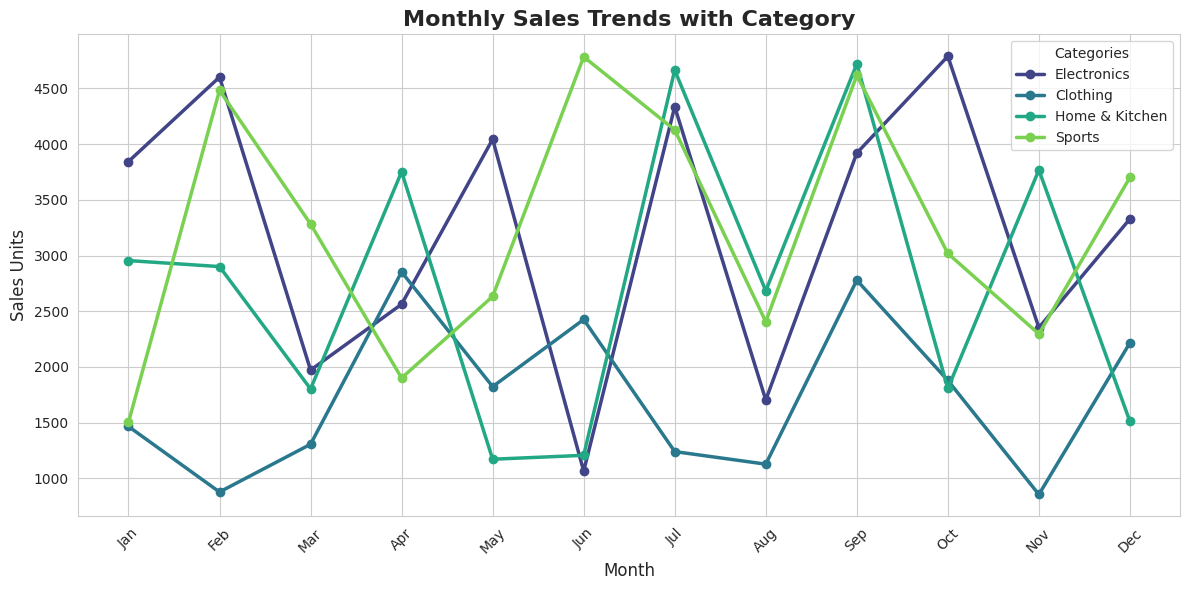

In [26]:
# Line Plot
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
colors = sns.color_palette("viridis", 4)
# Plot lines using gradient colors
for i, column in enumerate(["Electronics", "Clothing", "Home & Kitchen", "Sports"]):
    plt.plot(df.index, df[column],
             marker='o',
             linewidth=2.5,
             color=colors[i],
             label=column)
plt.title("Monthly Sales Trends with Category", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Sales Units", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Categories")
plt.tight_layout()
plt.show()

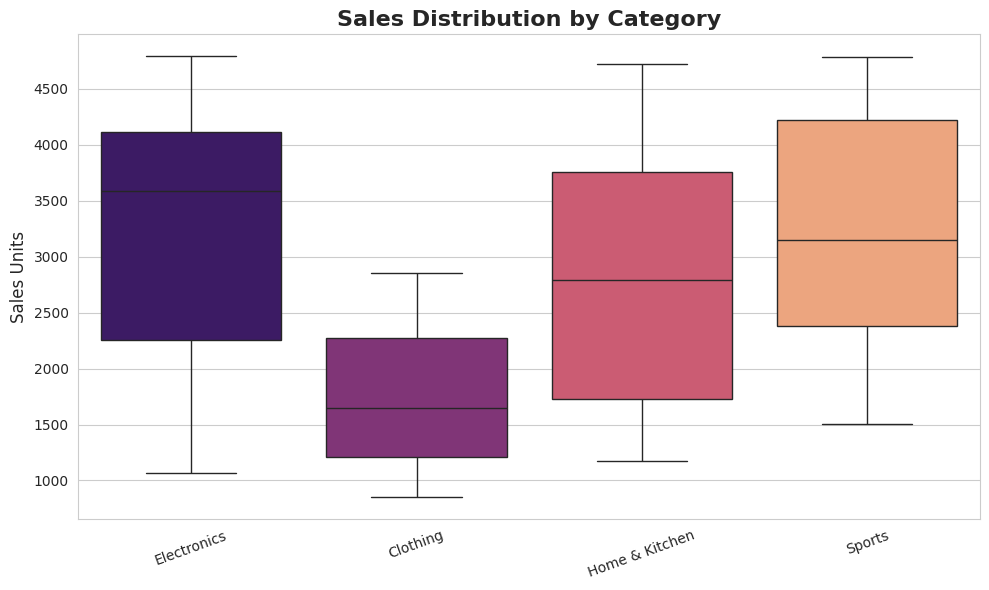

In [28]:
# Box Plot
plt.figure(figsize=(10, 6))
gradient_palette = sns.color_palette("magma", 4)
sns.boxplot(
    data=df[["Electronics", "Clothing", "Home & Kitchen", "Sports"]],
    palette=gradient_palette
)
plt.title("Sales Distribution by Category", fontsize=16, fontweight="bold")
plt.ylabel("Sales Units", fontsize=12)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Q.2 For the array: array = np.array([[1, -2, 3],[-4, 5, -6]])
i. Find element-wise absolute value.
ii. Find the 25th, 50th, and 75th percentile of flattened array, for each column, for each row.
iii. Mean, Median and Standard Deviation of flattened array, of each column, and
each row.


In this question, I first calculated the element-wise absolute value of the given array to convert all negative numbers into positive values. Then, I found the 25th, 50th (median), and 75th percentiles for the flattened array to understand the overall distribution of the data. After that, I calculated the same percentiles separately for each column and each row to analyze how the values are distributed across different dimensions.
Finally, I computed the mean, median, and standard deviation for the flattened array, as well as column-wise and row-wise. These measures help in understanding the central tendency and spread of the data.

In [36]:
import numpy as np
array = np.array([[1, -2, 3],
                  [-4, 5, -6]])
# i) Element-wise absolute value
abs_array = np.abs(array)
print("Absolute Value:\n", abs_array)

print("\n2nd part starts from here")
# ii) Percentiles (25th, 50th, 75th)
# Flatten the array
flat_array = array.flatten()
percentiles_flat = np.percentile(flat_array, [25, 50, 75])
print("Percentiles of Flattened Array (25th, 50th, 75th):")
print(percentiles_flat)


# Column-wise percentiles
percentiles_column = np.percentile(array, [25, 50, 75], axis=0)
print("\nPercentiles for Each Column:")
print(percentiles_column)


# Row-wise percentiles
percentiles_row = np.percentile(array, [25, 50, 75], axis=1)
print("\nPercentiles for Each Row:")
print(percentiles_row)



print("\n3rd part starts from here")
# iii) Mean, Median, Standard Deviation
print("Flattened Array Statistics:")
print("Mean:", np.mean(flat_array))
print("Median:", np.median(flat_array))
print("Standard Deviation:", np.std(flat_array))


print("\nColumn-wise Statistics:")
print("Mean:", np.mean(array, axis=0))
print("Median:", np.median(array, axis=0))
print("Standard Deviation:", np.std(array, axis=0))


print("\nColumn-wise Statistics:")
print("Mean:", np.mean(array, axis=0))
print("Median:", np.median(array, axis=0))
print("Standard Deviation:", np.std(array, axis=0))

Absolute Value:
 [[1 2 3]
 [4 5 6]]

2nd part starts from here
Percentiles of Flattened Array (25th, 50th, 75th):
[-3.5 -0.5  2.5]

Percentiles for Each Column:
[[-2.75 -0.25 -3.75]
 [-1.5   1.5  -1.5 ]
 [-0.25  3.25  0.75]]

Percentiles for Each Row:
[[-0.5 -5. ]
 [ 1.  -4. ]
 [ 2.   0.5]]

3rd part starts from here
Flattened Array Statistics:
Mean: -0.5
Median: -0.5
Standard Deviation: 3.8622100754188224

Column-wise Statistics:
Mean: [-1.5  1.5 -1.5]
Median: [-1.5  1.5 -1.5]
Standard Deviation: [2.5 3.5 4.5]

Column-wise Statistics:
Mean: [-1.5  1.5 -1.5]
Median: [-1.5  1.5 -1.5]
Standard Deviation: [2.5 3.5 4.5]


Q.3 For the array: a = np.array([-1.8, -1.6, -0.5, 0.5,1.6, 1.8, 3.0]).
i. Find floor, ceiling and truncated value,rounded values.

I applied different rounding functions to the given array to observe how each method behaves. The floor function rounds each value down to the nearest smaller integer, while the ceiling function rounds it up to the nearest larger integer. The truncate function simply removes the decimal part without rounding, moving the value toward zero. Finally, the round function gives the nearest integer value. These operations help in understanding different ways of approximating decimal numbers.

In [37]:
import numpy as np
a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])
# Floor values (round down)
floor_values = np.floor(a)
# Ceiling values (round up)
ceil_values = np.ceil(a)
# Truncated values (remove decimal part)
trunc_values = np.trunc(a)
# Rounded values (nearest integer)
round_values = np.round(a)
print("Original Array:", a)
print("Floor Values:", floor_values)
print("Ceiling Values:", ceil_values)
print("Truncated Values:", trunc_values)
print("Rounded Values:", round_values)

Original Array: [-1.8 -1.6 -0.5  0.5  1.6  1.8  3. ]
Floor Values: [-2. -2. -1.  0.  1.  1.  3.]
Ceiling Values: [-1. -1. -0.  1.  2.  2.  3.]
Truncated Values: [-1. -1. -0.  0.  1.  1.  3.]
Rounded Values: [-2. -2. -0.  0.  2.  2.  3.]


Q.4 WAP to swap two elementsin a list in Python Using a Temporary Variable.

In this program, I swapped two elements of a list using a temporary variable. First, I stored one element in a temporary variable. Then, I replaced the first element with the second one and finally assigned the temporary value to the second position. This method ensures that the original value is not lost during swapping.

In [40]:
my_list = [10, 20, 30, 40]
print("Original List:", my_list)
# Positions to swap (for example index 1 and 3)
i = 1
j = 3
# We are swapping here by using a temporary variable
temp = my_list[i]
my_list[i] = my_list[j]
my_list[j] = temp
print("List After Swapping:", my_list)

Original List: [10, 20, 30, 40]
List After Swapping: [10, 40, 30, 20]


Q.5 Write a Python program to swap two elementsin a set by converting it to a list first.

As we all know that sets do not support indexing, I first converted the set into a list. After converting, I swapped two elements using a temporary variable. Finally, I converted the list back into a set. This allows swapping elements even though sets are unordered collections.

In [45]:
my_set = {10, 20, 30, 40}
print("Original Set:", my_set)
# Convert set to list
temp_list = list(my_set)
# Choose two positions to swap
i = 0
j = 1
# Swap
temp = temp_list[i]
temp_list[i] = temp_list[j]
temp_list[j] = temp
my_set = set(temp_list)
print("Set After Swapping:", my_set)

Original Set: {40, 10, 20, 30}
Set After Swapping: {40, 10, 20, 30}
